# DBSCAN — Density-Based Spatial Clustering of Applications with Noise

**What you'll learn:** How to find clusters of arbitrary shape in noisy data — without specifying the number of clusters in advance.

**Why it matters:** K-Means assumes spherical clusters and requires you to pick $k$. Real-world data often has clusters shaped like crescents, spirals, or blobs of wildly different sizes, surrounded by random noise. DBSCAN handles all of this naturally.

**Prerequisites:** Python, NumPy, basic geometry (distance, neighborhoods).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import ipywidgets as widgets
from IPython.display import display

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
})

COLORS = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy",
          "orchid", "goldenrod", "teal"]
NOISE_COLOR = "#aaaaaa"

rng = np.random.default_rng(42)
print("Libraries loaded.")

Libraries loaded.


---

## 1 · The Core Idea: Density

DBSCAN's fundamental premise: **a cluster is a dense region of points separated from other dense regions by sparse regions.**

Instead of asking "which centroid is this point closest to?", DBSCAN asks: "does this point live in a dense enough neighborhood?"

### The two hyperparameters

| Symbol | Name | Meaning |
|--------|------|---------|
| $\varepsilon$ | epsilon | radius of the neighborhood around each point |
| $\text{MinPts}$ | min_samples | minimum points required inside the $\varepsilon$-ball to be "dense" |

### Three types of points

Given $\varepsilon$ and $\text{MinPts}$, every point in the dataset is classified as one of:

**Core point** — has at least $\text{MinPts}$ neighbors within radius $\varepsilon$ (including itself):

$$|N_\varepsilon(p)| \geq \text{MinPts} \quad \text{where} \quad N_\varepsilon(p) = \{q \in D : \|p - q\| \leq \varepsilon\}$$

**Border point** — within $\varepsilon$ of a core point, but not a core point itself (not dense enough on its own).

**Noise point** — neither core nor border. It's an outlier.

> **Key insight:** Clusters grow outward from core points by "infecting" neighbors. Two core points that can reach each other through a chain of core-to-core hops end up in the same cluster.

---

## 2 · Density-Reachability & Connectivity

These formal definitions explain exactly how clusters are formed.

### Directly density-reachable
$q$ is **directly density-reachable** from $p$ if:
1. $q \in N_\varepsilon(p)$ (q is within ε of p), AND
2. $p$ is a core point

Note: this relation is **not symmetric** — a border point can be reached from a core point, but not vice versa.

### Density-reachable
$q$ is **density-reachable** from $p$ if there exists a chain of points $p = p_1, p_2, \ldots, p_n = q$ where each $p_{i+1}$ is directly density-reachable from $p_i$.

This is the transitive closure — it lets clusters "snake" through space along dense paths.

### Density-connected
$p$ and $q$ are **density-connected** if there exists some core point $o$ such that both $p$ and $q$ are density-reachable from $o$.

### Cluster definition
A cluster $C$ is a non-empty set of points satisfying:
- **Maximality:** if $p \in C$, $p$ is a core point, and $q$ is density-reachable from $p$, then $q \in C$
- **Connectivity:** every two points in $C$ are density-connected

$$\text{Noise} = D \setminus \bigcup_i C_i$$

---

## 3 · Dataset

We'll use three synthetic datasets that showcase DBSCAN's strengths — shapes that completely defeat K-Means:

- **Two moons** — non-convex, interleaved crescents
- **Concentric rings** — one cluster inside another
- **Blobs + noise** — classic case with random outliers

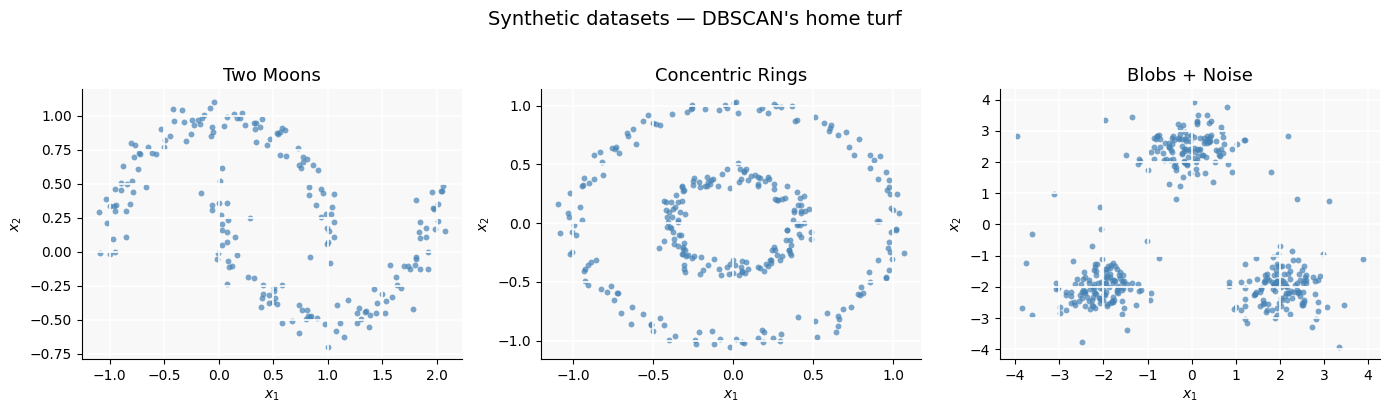

In [2]:
def make_moons(n=200, noise=0.08, seed=42):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, np.pi, n // 2)
    x1 = np.c_[np.cos(t), np.sin(t)]
    x2 = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]
    X = np.vstack([x1, x2]) + rng.normal(0, noise, (n, 2))
    return X

def make_circles(n=300, noise=0.05, factor=0.4, seed=42):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 2 * np.pi, n // 2)
    outer = np.c_[np.cos(t), np.sin(t)] + rng.normal(0, noise, (n // 2, 2))
    inner = factor * np.c_[np.cos(t), np.sin(t)] + rng.normal(0, noise, (n // 2, 2))
    return np.vstack([outer, inner])

def make_blobs_with_noise(n_per_blob=120, noise_pts=30, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array([[-2, -2], [2, -2], [0, 2.5]])
    blobs = [rng.normal(c, 0.5, (n_per_blob, 2)) for c in centers]
    noise = rng.uniform(-4, 4, (noise_pts, 2))
    return np.vstack(blobs + [noise])

X_moons   = make_moons()
X_circles = make_circles()
X_blobs   = make_blobs_with_noise()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, X, title in zip(axes,
                         [X_moons, X_circles, X_blobs],
                         ["Two Moons", "Concentric Rings", "Blobs + Noise"]):
    ax.scatter(X[:, 0], X[:, 1], s=18, color="steelblue", alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.suptitle("Synthetic datasets — DBSCAN's home turf", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 4 · The DBSCAN Algorithm from Scratch

The algorithm is a BFS/DFS flood-fill through the density graph. Here's the pseudocode:

```
for each unvisited point p:
    mark p as visited
    find all neighbors N = {q : dist(p,q) ≤ ε}
    if |N| < MinPts:
        label p as NOISE  (may be reassigned later as a border point)
    else:
        start a new cluster C
        add p to C
        queue = N  (seed queue)
        while queue not empty:
            q = queue.pop()
            if q is NOISE → relabel q as border point of C
            if q is unvisited:
                mark q as visited
                find q's neighbors N'
                if |N'| ≥ MinPts → queue.extend(N')  (q is also a core point)
            if q not yet in any cluster → add q to C
```

> **Key insight:** Only core points propagate the cluster expansion. Border points join but don't "infect" further. This is why a cluster can have a thin boundary without those border points pulling noise in.

In [3]:
def euclidean_distances(X):
    """Compute full pairwise distance matrix. O(n²) — fine for small n."""
    diff = X[:, None, :] - X[None, :, :]   # (n, n, d)
    return np.sqrt((diff ** 2).sum(axis=-1))

def dbscan(X, eps, min_samples):
    """
    Returns
    -------
    labels : ndarray of shape (n,)
        Cluster id for each point. -1 = noise.
    core_mask : ndarray of bool, shape (n,)
        True if the point is a core point.
    """
    n = len(X)
    D = euclidean_distances(X)

    # neighbors[i] = sorted list of indices within eps of point i
    neighbors = [np.where(D[i] <= eps)[0] for i in range(n)]

    core_mask = np.array([len(nb) >= min_samples for nb in neighbors])

    labels    = np.full(n, -1, dtype=int)   # -1 = unassigned / noise
    visited   = np.zeros(n, dtype=bool)

    cluster_id = 0

    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True

        if not core_mask[i]:
            # Tentatively noise; may be re-labeled when a core point claims it
            continue

        # Expand cluster from core point i
        labels[i] = cluster_id
        queue = deque(neighbors[i])

        while queue:
            j = queue.popleft()

            if labels[j] == -1:          # was noise → becomes border point
                labels[j] = cluster_id

            if visited[j]:
                continue

            visited[j] = True
            labels[j]  = cluster_id

            if core_mask[j]:             # j is also a core point → propagate
                queue.extend(neighbors[j])

        cluster_id += 1

    return labels, core_mask

# Quick test on moons
labels, core_mask = dbscan(X_moons, eps=0.2, min_samples=5)
n_clusters = labels.max() + 1
n_noise    = (labels == -1).sum()
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} / {len(X_moons)}")
print(f"Core points    : {core_mask.sum()}")

Clusters found : 2
Noise points   : 0 / 200
Core points    : 193


---

## 5 · Visualizing Point Types: Core, Border, Noise

Before looking at the final clusters, let's see how DBSCAN classifies individual points. We'll draw $\varepsilon$-circles around a few core points to make the neighborhood concept concrete.

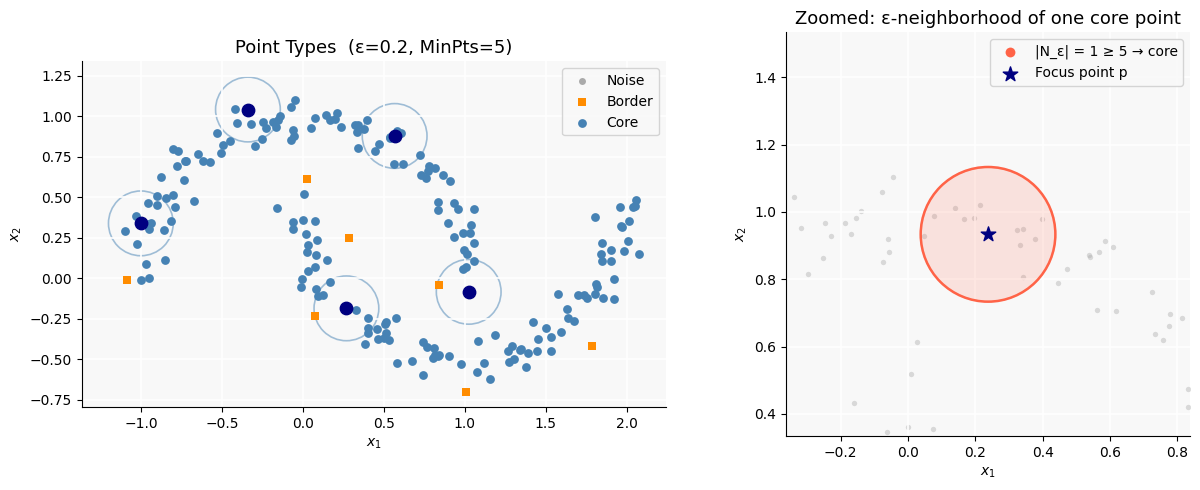

Core: 193  Border: 7  Noise: 0


In [4]:
EPS, MIN_SAMPLES = 0.2, 5

labels_m, core_m = dbscan(X_moons, EPS, MIN_SAMPLES)

# Classify border vs noise among non-core points
# border = non-core but assigned to a cluster; noise = still -1
border_m = (~core_m) & (labels_m != -1)
noise_m  = labels_m == -1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: point type classification ---
ax1.scatter(X_moons[noise_m,  0], X_moons[noise_m,  1],
            s=25, color=NOISE_COLOR, label="Noise", zorder=2, linewidths=0)
ax1.scatter(X_moons[border_m, 0], X_moons[border_m, 1],
            s=35, color="darkorange", marker="s", label="Border", zorder=3, linewidths=0)
ax1.scatter(X_moons[core_m,   0], X_moons[core_m,   1],
            s=40, color="steelblue", label="Core", zorder=4, linewidths=0)

# Draw ε-circles around a few core points for illustration
sample_cores = np.where(core_m)[0][::30][:5]
for idx in sample_cores:
    circle = mpatches.Circle(X_moons[idx], EPS,
                              fill=False, edgecolor="steelblue",
                              linewidth=1.2, alpha=0.5, zorder=1)
    ax1.add_patch(circle)
    ax1.scatter(*X_moons[idx], s=80, color="navy", zorder=5)

ax1.set_aspect("equal")
ax1.set_title(f"Point Types  (ε={EPS}, MinPts={MIN_SAMPLES})", fontsize=13)
ax1.set_xlabel("$x_1$"); ax1.set_ylabel("$x_2$")
ax1.legend(fontsize=10)

# --- Right: zoomed-in ε-neighborhood diagram ---
focus_idx = np.where(core_m)[0][40]
focus_pt  = X_moons[focus_idx]
nearby    = np.where(euclidean_distances(X_moons[[focus_idx], :])[0] <= EPS)[0]

ax2.scatter(X_moons[:, 0], X_moons[:, 1],
            s=15, color=NOISE_COLOR, alpha=0.4, linewidths=0, zorder=1)
ax2.scatter(X_moons[nearby, 0], X_moons[nearby, 1],
            s=50, color="tomato", zorder=3, label=f"|N_ε| = {len(nearby)} ≥ {MIN_SAMPLES} → core", linewidths=0)
ax2.scatter(*focus_pt, s=120, color="navy", zorder=4, label="Focus point p", marker="*")

circle2 = mpatches.Circle(focus_pt, EPS,
                           fill=True, facecolor="tomato",
                           edgecolor="tomato", linewidth=1.5, alpha=0.15, zorder=2)
ax2.add_patch(circle2)
circle2b = mpatches.Circle(focus_pt, EPS,
                            fill=False, edgecolor="tomato", linewidth=1.8, zorder=5)
ax2.add_patch(circle2b)

margin = 0.6
ax2.set_xlim(focus_pt[0] - margin, focus_pt[0] + margin)
ax2.set_ylim(focus_pt[1] - margin, focus_pt[1] + margin)
ax2.set_aspect("equal")
ax2.set_title("Zoomed: ε-neighborhood of one core point", fontsize=13)
ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Core: {core_m.sum()}  Border: {border_m.sum()}  Noise: {noise_m.sum()}")

---

## 6 · Clustering Results on All Three Datasets

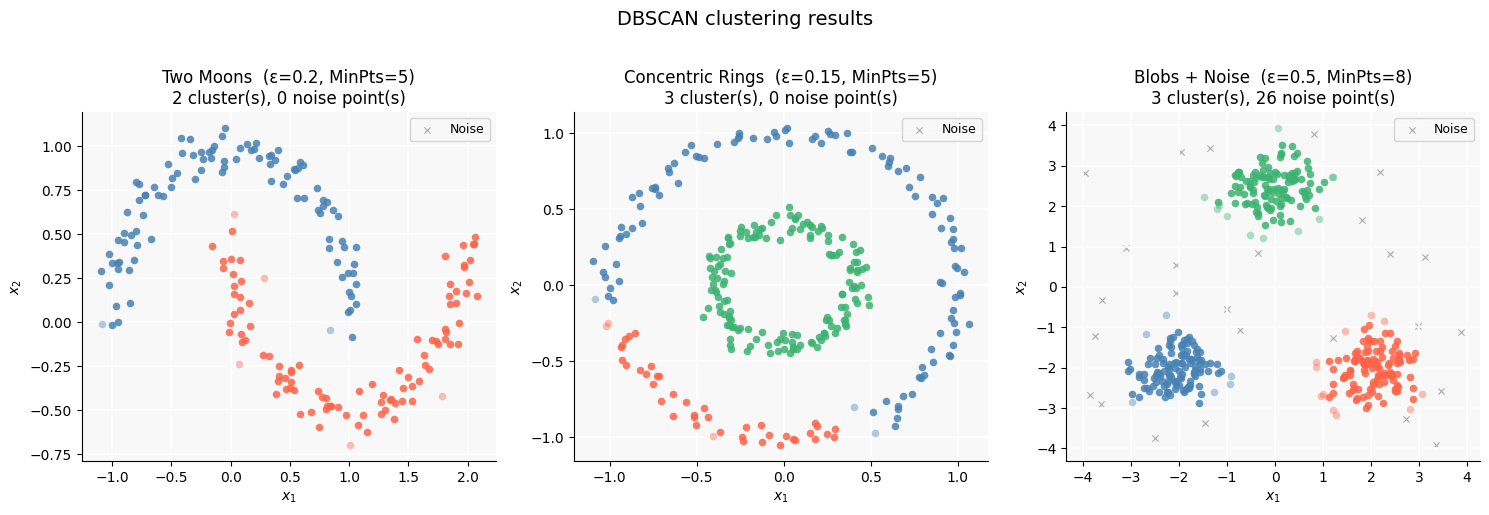

In [5]:
def plot_clusters(ax, X, labels, core_mask, title):
    unique = sorted(set(labels) - {-1})
    for cid in unique:
        mask = labels == cid
        ax.scatter(X[mask & core_mask,  0], X[mask & core_mask,  1],
                   s=30, color=COLORS[cid % len(COLORS)], alpha=0.85,
                   linewidths=0, zorder=3)
        ax.scatter(X[mask & ~core_mask, 0], X[mask & ~core_mask, 1],
                   s=30, color=COLORS[cid % len(COLORS)], alpha=0.4,
                   linewidths=0, zorder=2)
    noise = labels == -1
    ax.scatter(X[noise, 0], X[noise, 1],
               s=20, color=NOISE_COLOR, marker="x", linewidths=0.8, zorder=1, label="Noise")
    n_cls = len(unique)
    n_noi = noise.sum()
    ax.set_title(f"{title}\n{n_cls} cluster(s), {n_noi} noise point(s)", fontsize=12)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

configs = [
    (X_moons,   0.20, 5,  "Two Moons"),
    (X_circles, 0.15, 5,  "Concentric Rings"),
    (X_blobs,   0.50, 8,  "Blobs + Noise"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (X, eps, mpts, title) in zip(axes, configs):
    lbl, core = dbscan(X, eps, mpts)
    plot_clusters(ax, X, lbl, core, f"{title}  (ε={eps}, MinPts={mpts})")
    ax.legend(fontsize=9)

plt.suptitle("DBSCAN clustering results", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 7 · Effect of Hyperparameters

$\varepsilon$ is the most sensitive knob. Too small → everything is noise. Too large → clusters merge.

$\text{MinPts}$ controls how "strict" the density threshold is. A rule of thumb: $\text{MinPts} \geq d + 1$ where $d$ is the number of dimensions, with 5 as a common default for 2D data.

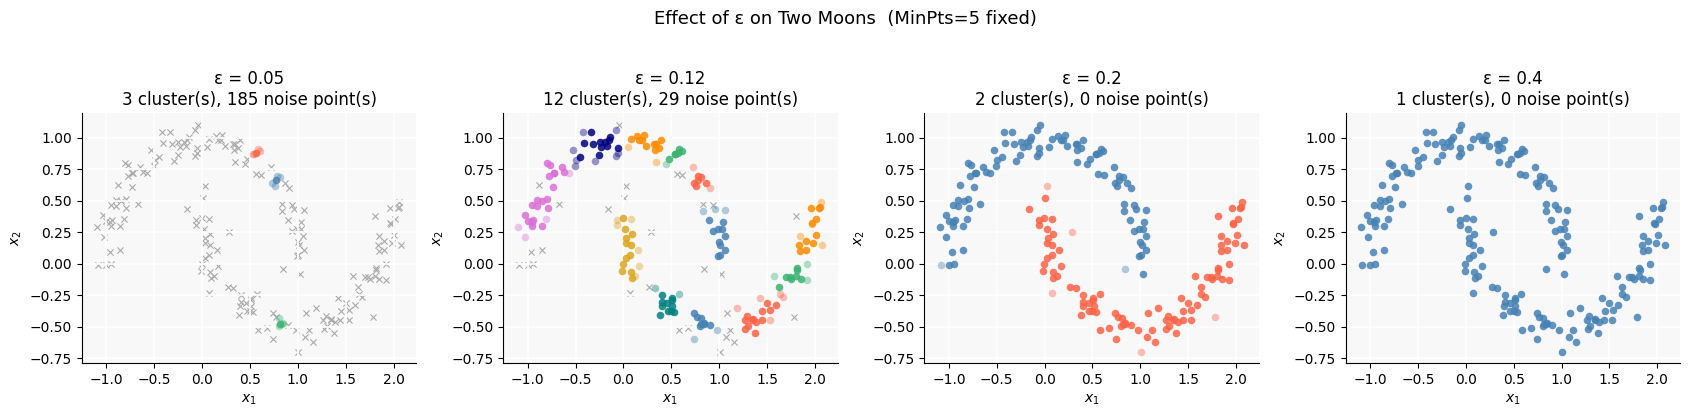

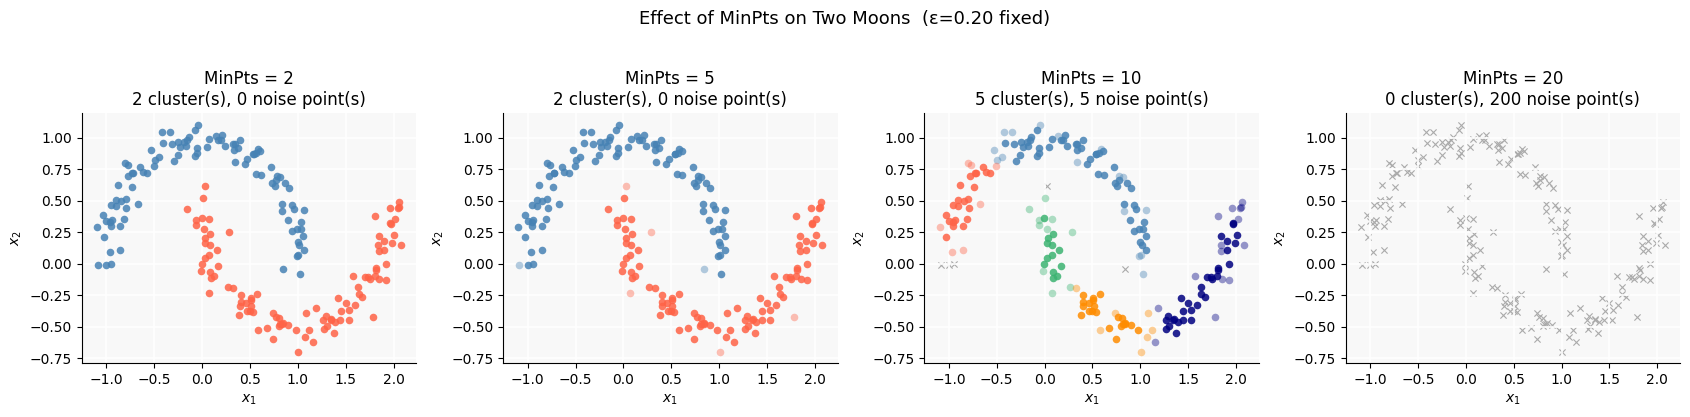

In [6]:
eps_values = [0.05, 0.12, 0.20, 0.40]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, eps in zip(axes, eps_values):
    lbl, core = dbscan(X_moons, eps=eps, min_samples=5)
    plot_clusters(ax, X_moons, lbl, core, f"ε = {eps}")

plt.suptitle("Effect of ε on Two Moons  (MinPts=5 fixed)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# --- Effect of MinPts ---
mpts_values = [2, 5, 10, 20]
fig2, axes2 = plt.subplots(1, 4, figsize=(17, 4))

for ax, mpts in zip(axes2, mpts_values):
    lbl, core = dbscan(X_moons, eps=0.20, min_samples=mpts)
    plot_clusters(ax, X_moons, lbl, core, f"MinPts = {mpts}")

plt.suptitle("Effect of MinPts on Two Moons  (ε=0.20 fixed)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

---

## 8 · Choosing ε: The k-Distance Plot

A principled way to choose $\varepsilon$: plot the distance to each point's $k$-th nearest neighbor (sorted). The "elbow" in this curve is a good $\varepsilon$ candidate.

**Why it works:** In a dense region, the $k$-NN distance is small and stable. At cluster boundaries it jumps sharply. That jump is the natural $\varepsilon$.

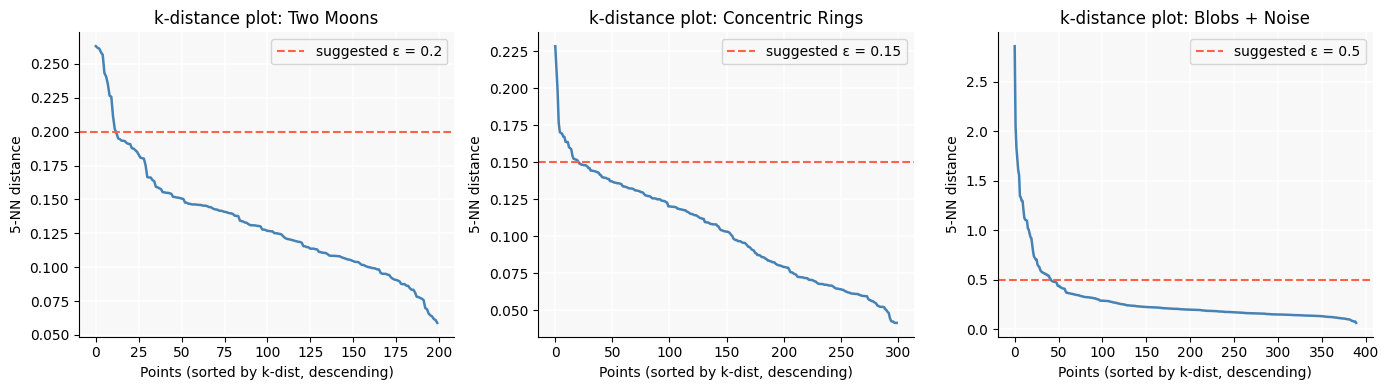

In [7]:
def k_distance_plot(X, k=5):
    D = euclidean_distances(X)
    kth_dist = np.sort(D, axis=1)[:, k]   # k-th nearest neighbor dist for each point
    return np.sort(kth_dist)[::-1]         # sort descending for the elbow plot

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
datasets = [(X_moons, "Two Moons"), (X_circles, "Concentric Rings"), (X_blobs, "Blobs + Noise")]
suggested_eps = [0.20, 0.15, 0.50]

for ax, (X, title), eps_hint in zip(axes, datasets, suggested_eps):
    kdist = k_distance_plot(X, k=5)
    ax.plot(kdist, color="steelblue", linewidth=1.8)
    ax.axhline(eps_hint, color="tomato", linestyle="--", linewidth=1.5,
               label=f"suggested ε = {eps_hint}")
    ax.set_xlabel("Points (sorted by k-dist, descending)")
    ax.set_ylabel("5-NN distance")
    ax.set_title(f"k-distance plot: {title}", fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---

## 9 · Interactive Widget: Explore ε and MinPts

Use the sliders to see in real time how $\varepsilon$ and $\text{MinPts}$ reshape the clusters on the moons dataset.

In [8]:
def interactive_dbscan(eps=0.20, min_samples=5):
    lbl, core = dbscan(X_moons, eps=eps, min_samples=min_samples)
    n_cls = lbl.max() + 1
    n_noi = (lbl == -1).sum()

    fig, ax = plt.subplots(figsize=(7, 5))
    plot_clusters(ax, X_moons, lbl, core, "")
    ax.set_title(f"ε={eps:.2f}  MinPts={min_samples}  →  {n_cls} cluster(s), {n_noi} noise pts",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

widgets.interact(
    interactive_dbscan,
    eps=widgets.FloatSlider(value=0.20, min=0.04, max=0.60, step=0.02,
                            description="ε", style={"description_width": "initial"}),
    min_samples=widgets.IntSlider(value=5, min=2, max=20, step=1,
                                  description="MinPts", style={"description_width": "initial"}),
);

interactive(children=(FloatSlider(value=0.2, description='ε', max=0.6, min=0.04, step=0.02, style=SliderStyle(…

---

## 10 · DBSCAN vs K-Means: When Each Wins

K-Means minimizes within-cluster variance, which implicitly assumes convex, roughly equal-sized, spherical clusters. DBSCAN makes no such assumption. Let's see the contrast directly.

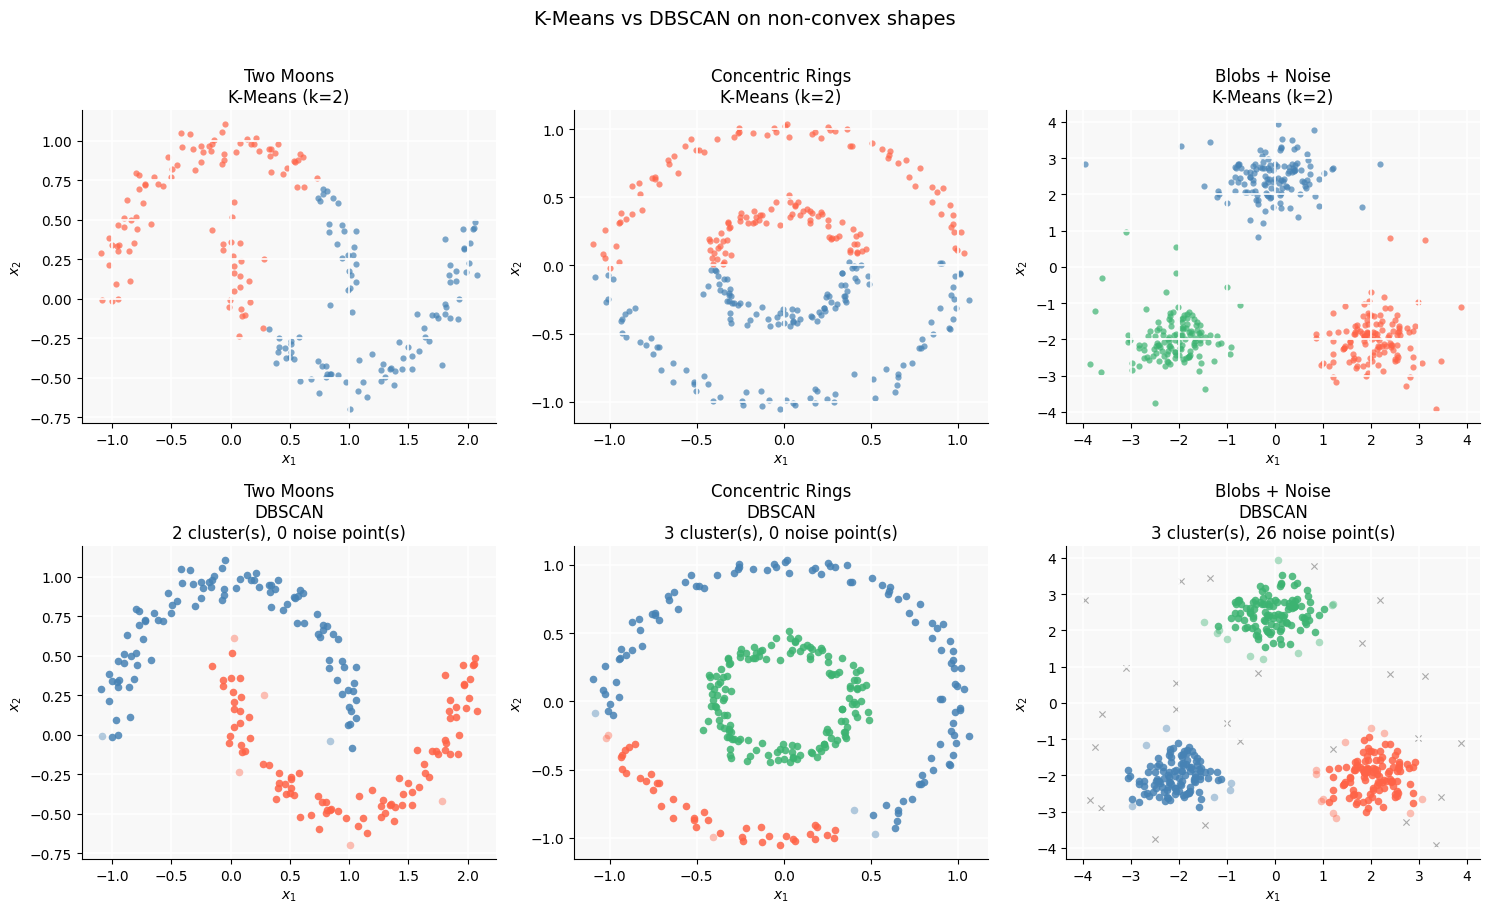

In [9]:
def kmeans(X, k, n_iter=300, seed=0):
    rng = np.random.default_rng(seed)
    centroids = X[rng.choice(len(X), k, replace=False)]
    for _ in range(n_iter):
        dists   = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # (n, k)
        labels  = dists.argmin(axis=1)
        new_c   = np.array([X[labels == i].mean(axis=0) if (labels == i).any()
                             else centroids[i] for i in range(k)])
        if np.allclose(centroids, new_c): break
        centroids = new_c
    return labels

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
row_titles = ["K-Means (k=2)", "DBSCAN"]
col_titles = ["Two Moons", "Concentric Rings", "Blobs + Noise"]
ds_configs = [
    (X_moons,   0.20, 5),
    (X_circles, 0.15, 5),
    (X_blobs,   0.50, 8),
]

for col, (X, eps, mpts) in enumerate(ds_configs):
    # K-Means row
    km_lbl = kmeans(X, k=2 if col < 2 else 3)
    ax_km  = axes[0][col]
    for cid in range(km_lbl.max() + 1):
        mask = km_lbl == cid
        ax_km.scatter(X[mask, 0], X[mask, 1],
                      s=20, color=COLORS[cid], alpha=0.7, linewidths=0)
    ax_km.set_title(f"{col_titles[col]}\n{row_titles[0]}", fontsize=12)
    ax_km.set_xlabel("$x_1$"); ax_km.set_ylabel("$x_2$")

    # DBSCAN row
    db_lbl, db_core = dbscan(X, eps, mpts)
    ax_db = axes[1][col]
    plot_clusters(ax_db, X, db_lbl, db_core, f"{col_titles[col]}\n{row_titles[1]}")

plt.suptitle("K-Means vs DBSCAN on non-convex shapes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

## 11 · Complexity & Practical Notes

### Time complexity

A naive implementation (like ours) computes all $n^2$ pairwise distances:

$$O(n^2) \text{ time}, \quad O(n^2) \text{ space}$$

With a spatial index (k-d tree or ball tree) neighbor lookups drop to $O(\log n)$ per point:

$$O(n \log n) \text{ average}, \quad O(n^2) \text{ worst case (high-dimensional data)}$$

> **Key insight:** The curse of dimensionality hurts DBSCAN badly in high dimensions — all points become equidistant and the notion of ε-neighborhood breaks down. DBSCAN works best in $d \leq 10$ dimensions.

### Limitations to know

| Issue | Cause | Workaround |
|-------|-------|-----------|
| Sensitive to ε | Small changes can merge/split clusters | Use k-distance plot to pick ε |
| Single global ε | Fails when clusters have different densities | HDBSCAN (hierarchical extension) |
| High-dim data | ε-balls become meaningless | Dimensionality reduction first |
| Border point ambiguity | A border point reachable from two clusters picks the first one visited | Rarely matters in practice |

---

## Summary

| Concept | Key Idea |
|---------|----------|
| **ε-neighborhood** $N_\varepsilon(p)$ | All points within Euclidean distance ε of point p |
| **Core point** | Has ≥ MinPts neighbors in its ε-neighborhood (including itself) |
| **Border point** | Within ε of a core point but not core itself |
| **Noise point** | Neither core nor border — an outlier |
| **Directly density-reachable** | q ∈ N_ε(p) and p is a core point |
| **Density-reachable** | Transitive chain of directly density-reachable hops |
| **Density-connected** | Both reachable from a common core point |
| **Cluster** | Maximal set of mutually density-connected points |
| **ε selection** | Read the elbow in the k-distance plot |
| **MinPts rule of thumb** | ≥ d+1 (dimension+1); 5 is a good default for 2D |
| **Advantage over K-Means** | Finds arbitrary-shape clusters; no need to specify k; handles noise natively |
| **Main limitation** | Single global ε fails when cluster densities differ — use HDBSCAN instead |
| **Complexity (naive)** | O(n²) time and space; O(n log n) with spatial indexing |